## Import Libraries

In [1]:
%%capture
import nltk
import pandas as pd
from sklearn.metrics import classification_report
from nltk.classify import NaiveBayesClassifier
import spacy
import sys
!pip install scispacy


### Import Dataset

In [2]:
Drug_lib_df = pd.read_csv("drugLibTest_NLP Final Project Dataset.csv")
Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,The antibiotic may have destroyed bacteria cau...,"Some back pain, some nauseau.",Took the antibiotics for 14 days. Sinus infect...
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,Lamictal stabilized my serious mood swings. On...,"Drowsiness, a bit of mental numbness. If you t...",Severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,Initial benefits were comparable to the brand ...,"Depakene has a very thin coating, which caused...",Depakote was prescribed to me by a Kaiser psyc...
3,969,sarafem,10,Highly Effective,No Side Effects,bi-polar / anxiety,It controlls my mood swings. It helps me think...,I didnt really notice any side effects.,This drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,Mild Side Effects,nodular acne,Within one week of treatment superficial acne ...,Side effects included moderate to severe dry s...,Drug was taken in gelatin tablet at 0.5 mg per...


In [3]:
print("number of drug_lib transcripts: ", len(Drug_lib_df))

number of drug_lib transcripts:  1036


In [4]:
%%capture
import sys
!{sys.executable} -m pip install spacy
!{sys.executable} -m pip install scispacy

In [5]:
from nltk.corpus import stopwords  # Stopword removal
from nltk.tokenize import word_tokenize  # Tokenization
from nltk.stem import WordNetLemmatizer  # Lemmatization

#### Rows With Null Values

In [6]:
#Check  rows with null values
Drug_lib_df.isnull().sum().sort_values(ascending = False)

sideEffectsReview    23
benefitsReview        5
commentsReview        1
Unnamed: 0            0
urlDrugName           0
rating                0
effectiveness         0
sideEffects           0
condition             0
dtype: int64

#### Removing Row With Null Values

In [7]:
#Remove rows with nulls
Drug_lib_df = Drug_lib_df[Drug_lib_df['sideEffectsReview'].notna()]
Drug_lib_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1013 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1013 non-null   int64 
 1   urlDrugName        1013 non-null   object
 2   rating             1013 non-null   int64 
 3   effectiveness      1013 non-null   object
 4   sideEffects        1013 non-null   object
 5   condition          1013 non-null   object
 6   benefitsReview     1008 non-null   object
 7   sideEffectsReview  1013 non-null   object
 8   commentsReview     1012 non-null   object
dtypes: int64(2), object(7)
memory usage: 79.1+ KB


In [8]:
#Remove rows with nulls
Drug_lib_df = Drug_lib_df[Drug_lib_df['benefitsReview'].notna()]
Drug_lib_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1008 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1008 non-null   int64 
 1   urlDrugName        1008 non-null   object
 2   rating             1008 non-null   int64 
 3   effectiveness      1008 non-null   object
 4   sideEffects        1008 non-null   object
 5   condition          1008 non-null   object
 6   benefitsReview     1008 non-null   object
 7   sideEffectsReview  1008 non-null   object
 8   commentsReview     1007 non-null   object
dtypes: int64(2), object(7)
memory usage: 78.8+ KB


In [9]:
#Remove rows with nulls
Drug_lib_df = Drug_lib_df[Drug_lib_df['commentsReview'].notna()]
Drug_lib_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1007 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1007 non-null   int64 
 1   urlDrugName        1007 non-null   object
 2   rating             1007 non-null   int64 
 3   effectiveness      1007 non-null   object
 4   sideEffects        1007 non-null   object
 5   condition          1007 non-null   object
 6   benefitsReview     1007 non-null   object
 7   sideEffectsReview  1007 non-null   object
 8   commentsReview     1007 non-null   object
dtypes: int64(2), object(7)
memory usage: 78.7+ KB


#### Converting Text into Lowercase

In [10]:
#Convert sideEffectsReview  into lowercase
Drug_lib_df['sideEffectsReview'] = Drug_lib_df['sideEffectsReview'].str.lower()
Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,The antibiotic may have destroyed bacteria cau...,"some back pain, some nauseau.",Took the antibiotics for 14 days. Sinus infect...
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,Lamictal stabilized my serious mood swings. On...,"drowsiness, a bit of mental numbness. if you t...",Severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,Initial benefits were comparable to the brand ...,"depakene has a very thin coating, which caused...",Depakote was prescribed to me by a Kaiser psyc...
3,969,sarafem,10,Highly Effective,No Side Effects,bi-polar / anxiety,It controlls my mood swings. It helps me think...,i didnt really notice any side effects.,This drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,Mild Side Effects,nodular acne,Within one week of treatment superficial acne ...,side effects included moderate to severe dry s...,Drug was taken in gelatin tablet at 0.5 mg per...


In [11]:
#Convert benefitsReview into lowercase
Drug_lib_df['commentsReview'] = Drug_lib_df['commentsReview'].astype(str).str.lower()

Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,The antibiotic may have destroyed bacteria cau...,"some back pain, some nauseau.",took the antibiotics for 14 days. sinus infect...
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,Lamictal stabilized my serious mood swings. On...,"drowsiness, a bit of mental numbness. if you t...",severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,Initial benefits were comparable to the brand ...,"depakene has a very thin coating, which caused...",depakote was prescribed to me by a kaiser psyc...
3,969,sarafem,10,Highly Effective,No Side Effects,bi-polar / anxiety,It controlls my mood swings. It helps me think...,i didnt really notice any side effects.,this drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,Mild Side Effects,nodular acne,Within one week of treatment superficial acne ...,side effects included moderate to severe dry s...,drug was taken in gelatin tablet at 0.5 mg per...


In [12]:
#Convert commentsReview into lowercase
Drug_lib_df['benefitsReview'] = Drug_lib_df['benefitsReview'].str.lower()
Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,Mild Side Effects,sinus infection,the antibiotic may have destroyed bacteria cau...,"some back pain, some nauseau.",took the antibiotics for 14 days. sinus infect...
1,3724,lamictal,9,Highly Effective,Mild Side Effects,bipolar disorder,lamictal stabilized my serious mood swings. on...,"drowsiness, a bit of mental numbness. if you t...",severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,initial benefits were comparable to the brand ...,"depakene has a very thin coating, which caused...",depakote was prescribed to me by a kaiser psyc...
3,969,sarafem,10,Highly Effective,No Side Effects,bi-polar / anxiety,it controlls my mood swings. it helps me think...,i didnt really notice any side effects.,this drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,Mild Side Effects,nodular acne,within one week of treatment superficial acne ...,side effects included moderate to severe dry s...,drug was taken in gelatin tablet at 0.5 mg per...


In [13]:
#Convert sideEffects into lowercase
Drug_lib_df['sideEffects'] = Drug_lib_df['sideEffects'].str.lower()
Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,Considerably Effective,mild side effects,sinus infection,the antibiotic may have destroyed bacteria cau...,"some back pain, some nauseau.",took the antibiotics for 14 days. sinus infect...
1,3724,lamictal,9,Highly Effective,mild side effects,bipolar disorder,lamictal stabilized my serious mood swings. on...,"drowsiness, a bit of mental numbness. if you t...",severe mood swings between hypomania and depre...
2,3824,depakene,4,Moderately Effective,severe side effects,bipolar disorder,initial benefits were comparable to the brand ...,"depakene has a very thin coating, which caused...",depakote was prescribed to me by a kaiser psyc...
3,969,sarafem,10,Highly Effective,no side effects,bi-polar / anxiety,it controlls my mood swings. it helps me think...,i didnt really notice any side effects.,this drug may not be for everyone but its wond...
4,696,accutane,10,Highly Effective,mild side effects,nodular acne,within one week of treatment superficial acne ...,side effects included moderate to severe dry s...,drug was taken in gelatin tablet at 0.5 mg per...


In [14]:
#Convert effectiveness into lowercase
Drug_lib_df['effectiveness'] = Drug_lib_df['effectiveness'].str.lower()
Drug_lib_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,1366,biaxin,9,considerably effective,mild side effects,sinus infection,the antibiotic may have destroyed bacteria cau...,"some back pain, some nauseau.",took the antibiotics for 14 days. sinus infect...
1,3724,lamictal,9,highly effective,mild side effects,bipolar disorder,lamictal stabilized my serious mood swings. on...,"drowsiness, a bit of mental numbness. if you t...",severe mood swings between hypomania and depre...
2,3824,depakene,4,moderately effective,severe side effects,bipolar disorder,initial benefits were comparable to the brand ...,"depakene has a very thin coating, which caused...",depakote was prescribed to me by a kaiser psyc...
3,969,sarafem,10,highly effective,no side effects,bi-polar / anxiety,it controlls my mood swings. it helps me think...,i didnt really notice any side effects.,this drug may not be for everyone but its wond...
4,696,accutane,10,highly effective,mild side effects,nodular acne,within one week of treatment superficial acne ...,side effects included moderate to severe dry s...,drug was taken in gelatin tablet at 0.5 mg per...


In [15]:
#Remove stop words

# Download the 'punkt_tab' resource before tokenization
nltk.download('punkt_tab') # Download the necessary data for punkt tokenizer

word_tokenized = nltk.word_tokenize(Drug_lib_df['sideEffectsReview'][0])
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('english')
word_tokenized = [word for word in word_tokenized if word not in stopwords]
print(word_tokenized)

['back', 'pain', ',', 'nauseau', '.']


In [16]:
sideEffectsReview = Drug_lib_df['sideEffectsReview']
sideEffects = Drug_lib_df ['sideEffects']
data_with_labels =list(zip(sideEffectsReview, sideEffects))
print ("data_with_labels[0]: ", data_with_labels[0])

data_with_labels[0]:  ('some back pain, some nauseau.', 'mild side effects')


In [17]:
urlDrugName = Drug_lib_df['urlDrugName']
condition = Drug_lib_df ['condition']
data_with_labels =list(zip(urlDrugName, condition))
print ("data_with_labels[0]: ", data_with_labels[0])

data_with_labels[0]:  ('biaxin', 'sinus infection')


#### Download Vader Lexicon

In [18]:
nltk.download('vader_lexicon')

True

#### Applying VADER Sentiment Analysis on Comments, Benefits, and Side Effects Reviews

In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Initialize VADER
sid = SentimentIntensityAnalyzer()


def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'




columns_to_check = ['commentsReview', 'benefitsReview', 'sideEffectsReview']

for col in columns_to_check:
    print(f"\nSentiment analysis for: {col}")
    Drug_lib_df['vader_compound'] = Drug_lib_df[col].astype(str).apply(lambda x: sid.polarity_scores(x)['compound'])
    Drug_lib_df['vader_label'] = Drug_lib_df['vader_compound'].apply(label_sentiment)
    sentiment_counts = Drug_lib_df['vader_label'].value_counts(normalize=True) * 100
    print(sentiment_counts)



Sentiment analysis for: commentsReview
vader_label
positive    36.345581
negative    35.451837
neutral     28.202582
Name: proportion, dtype: float64

Sentiment analysis for: benefitsReview
vader_label
positive    46.772592
negative    38.828203
neutral     14.399206
Name: proportion, dtype: float64

Sentiment analysis for: sideEffectsReview
vader_label
negative    54.419067
neutral     25.521351
positive    20.059583
Name: proportion, dtype: float64


In [20]:
%%capture
!pip install transformers torch

### Load BERT Tokenizer and Model for Sentiment Analysis

In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TextClassificationPipeline

model_name = "nlptown/bert-base-multilingual-uncased-sentiment" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)



from transformers import pipeline

# Load the sentiment analysis pipeline with truncation enabled
sentiment_pipeline = pipeline("sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,)

#  Create Text Classification Pipeline
health_sentiment = TextClassificationPipeline(model=model, tokenizer=tokenizer, return_all_scores=False)


reviews = Drug_lib_df['benefitsReview'].astype(str).tolist()
sentiment_results = sentiment_pipeline(reviews)

# Extract labels and scores
sentiment_labels = [result['label'] for result in sentiment_results]
sentiment_scores = [result['score'] for result in sentiment_results]



Drug_lib_df['bert_sentiment_label'] = sentiment_labels
Drug_lib_df['bert_sentiment_score'] = sentiment_scores


Device set to use mps:0
Device set to use mps:0
/opt/anaconda3/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [22]:
#from transformers import pipeline


# Function to truncate text and avoid token limit errors
def get_bert_sentiment(text):
    return sentiment_pipeline(text)[0]['label']

# Apply the function to the dataset
Drug_lib_df['benefitsReview_raw'] = Drug_lib_df['benefitsReview'].apply(lambda x: get_bert_sentiment(str(x)))

# Convert rating (1-5 stars) to positive, neutral, negative
def simplify(label):
    stars = int(label[0]) 
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

Drug_lib_df['benefitsReview_sentiment'] = Drug_lib_df['benefitsReview_raw'].apply(simplify)

# Show results
Drug_lib_df[['benefitsReview', 'benefitsReview_raw', 'benefitsReview_sentiment']].head()

,benefitsReview,benefitsReview_raw,benefitsReview_sentiment
0,the antibiotic may have destroyed bacteria cau...,3 stars,neutral
1,lamictal stabilized my serious mood swings. on...,5 stars,positive
2,initial benefits were comparable to the brand ...,4 stars,positive
3,it controlls my mood swings. it helps me think...,5 stars,positive
4,within one week of treatment superficial acne ...,1 star,negative


In [23]:
# Calculate sentiment distribution as percentages
bert_sentiments = Drug_lib_df['benefitsReview_sentiment'].value_counts(normalize=True).mul(100).round(1).to_dict()
print(bert_sentiments)


{'positive': 41.8, 'negative': 41.8, 'neutral': 16.4}


In [24]:
#from transformers import pipeline


# Function to truncate text and avoid token limit errors
def get_bert_sentiment(text):
    return sentiment_pipeline(text)[0]['label']

# Apply the function to the dataset
Drug_lib_df['commentsReview_raw'] = Drug_lib_df['commentsReview'].apply(lambda x: get_bert_sentiment(str(x)))

# Convert rating (1-5 stars) to positive, neutral, negative
def simplify(label):
    stars = int(label[0])  # Extract the first digit
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

Drug_lib_df['commentsReview_sentiment'] = Drug_lib_df['commentsReview_raw'].apply(simplify)

# Show results
Drug_lib_df[['commentsReview', 'commentsReview_raw', 'commentsReview_sentiment']].head()

,commentsReview,commentsReview_raw,commentsReview_sentiment
0,took the antibiotics for 14 days. sinus infect...,1 star,negative
1,severe mood swings between hypomania and depre...,2 stars,negative
2,depakote was prescribed to me by a kaiser psyc...,2 stars,negative
3,this drug may not be for everyone but its wond...,5 stars,positive
4,drug was taken in gelatin tablet at 0.5 mg per...,1 star,negative


In [25]:
# Calculate sentiment distribution as percentages
bert_sentiments = Drug_lib_df['commentsReview_sentiment'].value_counts(normalize=True).mul(100).round(1).to_dict()
print(bert_sentiments)


{'negative': 49.3, 'positive': 39.1, 'neutral': 11.6}


### Visualization in Matplolib

In [26]:
# Example results – replace with your actual computed percentages
vader_sentiments = {
    'Benefits': {'Positive': 46.7, 'Negative': 38.8, 'Neutral': 14.3},
    'Side Effects': {'Positive': 20.0, 'Negative': 54.4, 'Neutral': 25.6},
    'Comments': {'Positive': 36.3, 'Negative': 35.4, 'Neutral':28.2 }
}

bert_sentiments = {'Positive': 41.8, 'Neutral': 16.4, 'Negative': 41.8}  # Example aggregate from BERT


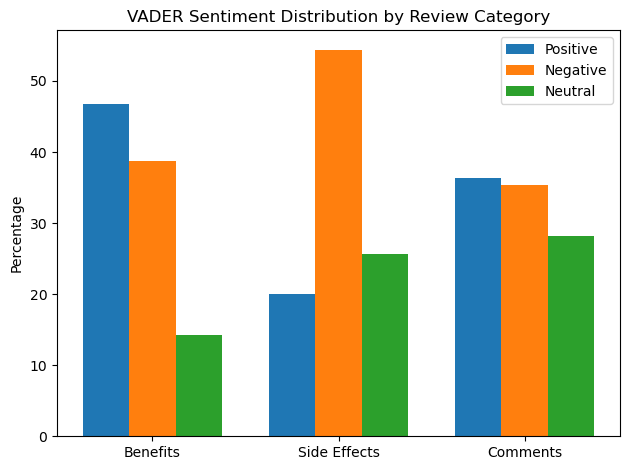

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
categories = list(vader_sentiments.keys())
labels = ['Positive', 'Negative', 'Neutral']
data = [[vader_sentiments[cat][label] for cat in categories] for label in labels]

x = np.arange(len(categories))  # the label locations
width = 0.25  # width of the bars

# Plot
fig, ax = plt.subplots()
rects1 = ax.bar(x - width, data[0], width, label='Positive')
rects2 = ax.bar(x, data[1], width, label='Negative')
rects3 = ax.bar(x + width, data[2], width, label='Neutral')

# Labels and formatting
ax.set_ylabel('Percentage')
ax.set_title('VADER Sentiment Distribution by Review Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.show()


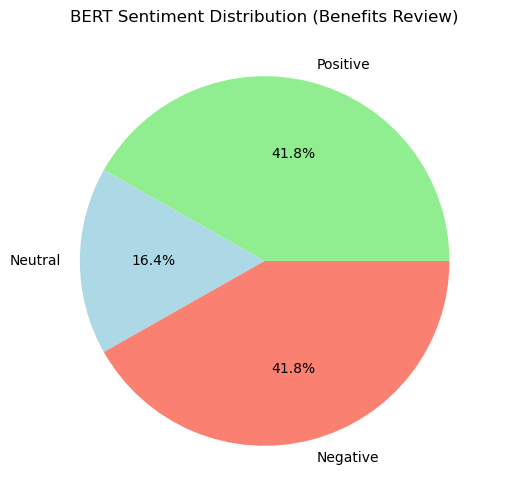

In [28]:
# Pie chart for BERT
colors = ['lightgreen', 'lightblue', 'salmon']
plt.figure(figsize=(6, 6))
plt.pie(bert_sentiments.values(), labels=bert_sentiments.keys(), autopct='%1.1f%%', colors=colors)
plt.title('BERT Sentiment Distribution (Benefits Review)')
plt.show()
